# <center> **Méthodes statistiques évaluation**

# Préambule

In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyfixest as pf
from linearmodels.panel import PanelOLS

In [2]:
ROOT_DIR = Path("..").resolve()
DATA_DIR = ROOT_DIR / "data" / "chapitre-2"
FIGURE_DIR = ROOT_DIR / "figure" / "chapitre-2"
TABLE_DIR = ROOT_DIR / "table" / "chapitre-2"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Exercice 1

# Préparation des données 

In [3]:
df1 = pd.read_csv(DATA_DIR / "panel-1.csv", sep=";")
df2 = pd.read_csv(DATA_DIR / "panel-2.csv", sep=";")
df3 = pd.read_csv(DATA_DIR / "panel-3.csv", sep=";")

In [4]:
df1

,id,year,month,y,treatment
0,1,2007,jan,-2.3095,1
1,1,2007,fev,-2.7723,1
2,1,2007,mar,-0.8818,1
3,1,2007,apr,-2.3803,1
4,1,2007,may,-2.4366,1
...,...,...,...,...,...
119995,1000,2016,aug,3.6324,0
119996,1000,2016,sep,8.3503,0
119997,1000,2016,oct,6.0415,0
119998,1000,2016,nov,7.8707,0


In [5]:
df2

,id,year,month,y,treatment
0,1,2007,jan,-2.2980,0
1,1,2007,fev,-1.4023,0
2,1,2007,mar,0.1533,0
3,1,2007,apr,-0.2325,0
4,1,2007,may,-2.4306,0
...,...,...,...,...,...
119995,1000,2016,aug,8.1111,0
119996,1000,2016,sep,6.1714,0
119997,1000,2016,oct,8.0962,0
119998,1000,2016,nov,7.5582,0


In [6]:
df3

,id,year,month,y,treatment
0,1,2007,jan,-7.3862,1
1,1,2007,fev,-7.2000,1
2,1,2007,mar,-2.4662,1
3,1,2007,apr,-6.8156,1
4,1,2007,may,-5.8128,1
...,...,...,...,...,...
119995,1000,2016,aug,7.1030,0
119996,1000,2016,sep,6.0816,0
119997,1000,2016,oct,6.0508,0
119998,1000,2016,nov,7.9724,0


In [7]:
dfs = [df1, df2, df3]

for df in dfs:
    df["treatment"] = df["treatment"].astype("category")

for i, df in enumerate(dfs):
    print(f"base {i + 1} : \n{df.dtypes}\n")

base 1 : 
id              int64
year            int64
month          object
y             float64
treatment    category
dtype: object

base 2 : 
id              int64
year            int64
month          object
y             float64
treatment    category
dtype: object

base 3 : 
id              int64
year            int64
month          object
y             float64
treatment    category
dtype: object



# Visualisation des données

In [8]:
month_map = {
    "jan": 1,
    "fev": 2,
    "mar": 3,
    "apr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "aug": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dec": 12,
}

for df in dfs:
    df["month_num"] = df["month"].map(
        month_map
    )  # créer une nouvelle colonne contenant le numéro du mois

    df["date"] = pd.to_datetime(
        df["year"].astype(str) + "-" + df["month_num"].astype(str), format="%Y-%m"
    ).dt.to_period(
        "M"
    )  # Période mensuelle

    date_en_nombre = df["year"] * 12 + df["month_num"]
    df["periode"] = date_en_nombre - date_en_nombre.min() + 1

    df.drop(columns=["month_num"], inplace=True)
    df["periode"] = df["periode"].astype(int)

print("Traité")
for i, df in enumerate(dfs):
    print(
        f"base {i+1} : {df.query('treatment == 1')['date'].min()} | période : {df.query('treatment == 1')['periode'].min()}"
    )

print("Non traité")
for i, df in enumerate(dfs):
    print(f"base {i+1} : {df.query('treatment == 0')['date'].min()}")

Traité
base 1 : 2007-01 | période : 1
base 2 : 2007-01 | période : 1
base 3 : 2007-01 | période : 1
Non traité
base 1 : 2007-01
base 2 : 2007-01
base 3 : 2007-01


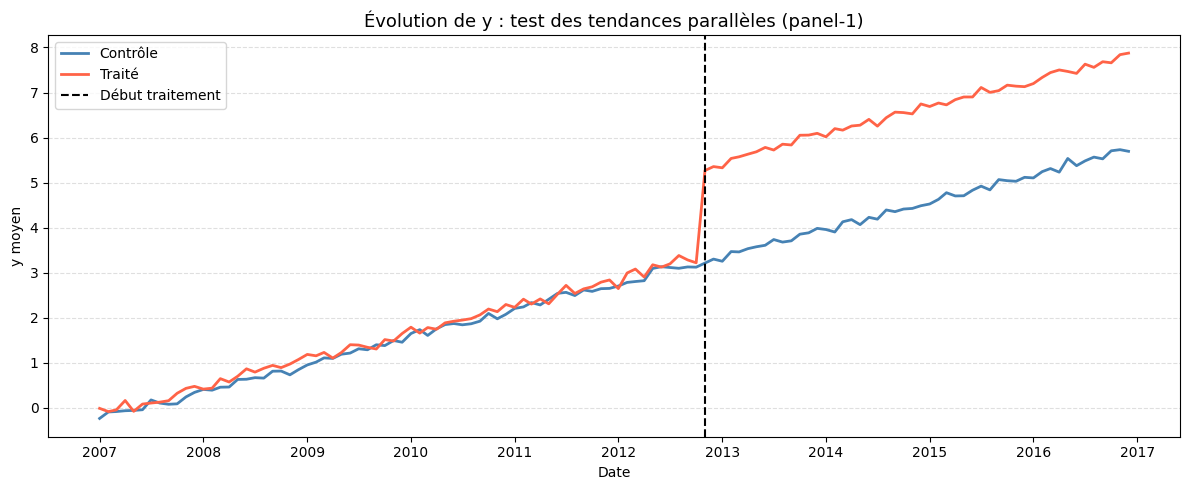

In [9]:
plot_df = df1.copy()
plot_df["date"] = plot_df["date"].dt.to_timestamp()

agg = plot_df.groupby(["date", "treatment"], observed=True)["y"].mean().reset_index()
controle = agg[agg["treatment"] == 0]
traite = agg[agg["treatment"] == 1]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(controle["date"], controle["y"], color="steelblue", lw=2, label="Contrôle")
ax.plot(traite["date"], traite["y"], color="tomato", lw=2, label="Traité")

ax.axvline(
    pd.Timestamp("2012-11-01"),
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Début traitement",
)

ax.set_title("Évolution de y : test des tendances parallèles (panel-1)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("y moyen")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "tendances-paralleles-panel-1.png")
plt.show()

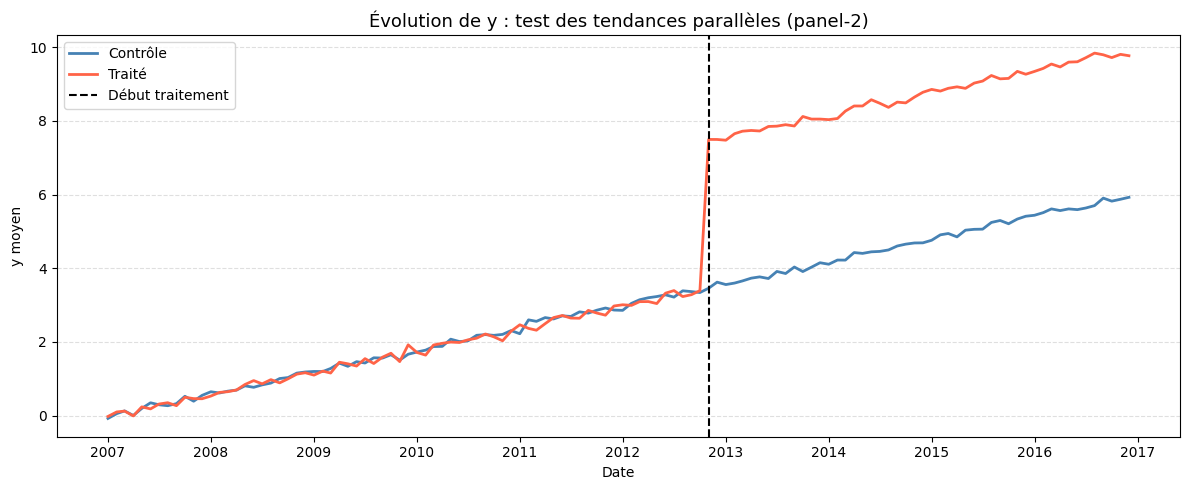

In [10]:
plot_df = df2.copy()
plot_df["date"] = plot_df["date"].dt.to_timestamp()

agg = plot_df.groupby(["date", "treatment"], observed=True)["y"].mean().reset_index()
controle = agg[agg["treatment"] == 0]
traite = agg[agg["treatment"] == 1]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(controle["date"], controle["y"], color="steelblue", lw=2, label="Contrôle")
ax.plot(traite["date"], traite["y"], color="tomato", lw=2, label="Traité")

ax.axvline(
    pd.Timestamp("2012-11-01"),
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Début traitement",
)

ax.set_title("Évolution de y : test des tendances parallèles (panel-2)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("y moyen")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "tendances-paralleles-panel-2.png")
plt.show()

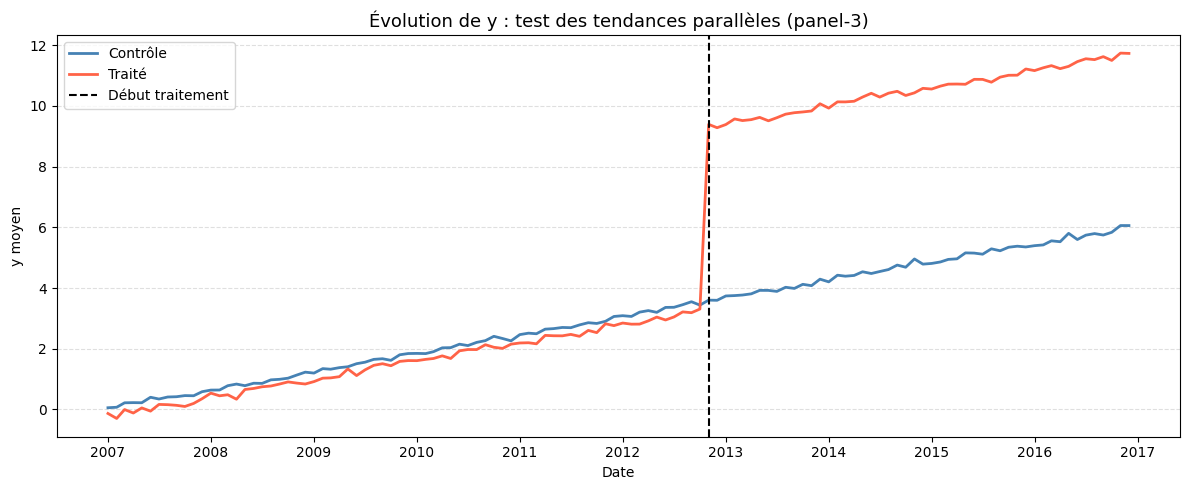

In [11]:
plot_df = df3.copy()
plot_df["date"] = plot_df["date"].dt.to_timestamp()

agg = plot_df.groupby(["date", "treatment"], observed=True)["y"].mean().reset_index()
controle = agg[agg["treatment"] == 0]
traite = agg[agg["treatment"] == 1]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(controle["date"], controle["y"], color="steelblue", lw=2, label="Contrôle")
ax.plot(traite["date"], traite["y"], color="tomato", lw=2, label="Traité")

ax.axvline(
    pd.Timestamp("2012-11-01"),
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Début traitement",
)

ax.set_title("Évolution de y : test des tendances parallèles (panel-3)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("y moyen")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "tendances-paralleles-panel-3.png")
plt.show()

# Modélisation

## Two-way fixed effects estimator (linearmodels)

In [12]:
df1["treatment"] = df1["treatment"].astype(int)
df1["post"] = (df1["periode"] >= 71).astype(int)
df1["did_interaction"] = df1["treatment"] * df1["post"]

df_panel1 = df1.set_index(["id", "periode"])

mod = PanelOLS.from_formula(
    "y ~ did_interaction + EntityEffects + TimeEffects",
    data=df_panel1,
    drop_absorbed=True,
)

res = mod.fit(cov_type="clustered", cluster_entity=True)
print(res.summary)

with open(TABLE_DIR / "twfe-panel-1.txt", "w") as f:
    f.write(res.summary.as_text())

                          PanelOLS Estimation Summary                           
Dep. Variable:                      y   R-squared:                        0.0945
Estimator:                   PanelOLS   R-squared (Between):              0.1130
No. Observations:              120000   R-squared (Within):               0.2280
Date:                Thu, Sep 10 2026   R-squared (Overall):              0.1431
Time:                        20:50:45   Log-likelihood                -2.188e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   1.241e+04
Entities:                        1000   P-value                           0.0000
Avg Obs:                       120.00   Distribution:                F(1,118880)
Min Obs:                       120.00                                           
Max Obs:                       120.00   F-statistic (robust):          1.156e+04
                            

In [13]:
df2["treatment"] = df2["treatment"].astype(int)
df2["post"] = (df2["periode"] >= 71).astype(int)
df2["did_interaction"] = df2["treatment"] * df2["post"]

df_panel2 = df2.set_index(["id", "periode"])

mod = PanelOLS.from_formula(
    "y ~ did_interaction + EntityEffects + TimeEffects",
    data=df_panel2,
    drop_absorbed=True,
)

res = mod.fit(cov_type="clustered", cluster_entity=True)
print(res.summary)

with open(TABLE_DIR / "twfe-panel-2.txt", "w") as f:
    f.write(res.summary.as_text())

                          PanelOLS Estimation Summary                           
Dep. Variable:                      y   R-squared:                        0.2939
Estimator:                   PanelOLS   R-squared (Between):              0.2156
No. Observations:              120000   R-squared (Within):               0.4223
Date:                Thu, Sep 10 2026   R-squared (Overall):              0.2742
Time:                        20:50:47   Log-likelihood                -2.181e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   4.948e+04
Entities:                        1000   P-value                           0.0000
Avg Obs:                       120.00   Distribution:                F(1,118880)
Min Obs:                       120.00                                           
Max Obs:                       120.00   F-statistic (robust):          4.921e+04
                            

In [14]:
df3["treatment"] = df3["treatment"].astype(int)
df3["post"] = (df3["periode"] >= 71).astype(int)
df3["did_interaction"] = df3["treatment"] * df3["post"]

df_panel3 = df3.set_index(["id", "periode"])

mod = PanelOLS.from_formula(
    "y ~ did_interaction + EntityEffects + TimeEffects",
    data=df_panel3,
    drop_absorbed=True,
)

res = mod.fit(cov_type="clustered", cluster_entity=True)
print(res.summary)

with open(TABLE_DIR / "twfe-panel-3.txt", "w") as f:
    f.write(res.summary.as_text())

                          PanelOLS Estimation Summary                           
Dep. Variable:                      y   R-squared:                        0.4835
Estimator:                   PanelOLS   R-squared (Between):              0.3036
No. Observations:              120000   R-squared (Within):               0.5696
Date:                Thu, Sep 10 2026   R-squared (Overall):              0.3880
Time:                        20:50:49   Log-likelihood                -2.182e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   1.113e+05
Entities:                        1000   P-value                           0.0000
Avg Obs:                       120.00   Distribution:                F(1,118880)
Min Obs:                       120.00                                           
Max Obs:                       120.00   F-statistic (robust):          1.096e+05
                            

## Difference in Difference model (pyfixest)

In [15]:
df1["treatment"] = df1["treatment"].astype(int)
df1["post"] = (df1["periode"] >= 71).astype(int)
df1["did_interaction"] = df1["treatment"] * df1["post"]

# Modèle DiD avec pyfixest
res = pf.feols(
    "y ~ did_interaction | id + periode",
    data=df1,
    vcov={"CRV1": "id"},
)
res.summary()

import io
from contextlib import redirect_stdout

buffer = io.StringIO()
with redirect_stdout(buffer):
    res.summary()
with open(TABLE_DIR / "did-panel-1.txt", "w") as f:
    f.write(buffer.getvalue())

###

Estimation:  OLS
Dep. var.: y, Fixed effects: id + periode
sample: None = all
Inference:  CRV1
Observations:  120000

| Coefficient     |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| did_interaction |      2.007 |        0.019 |   107.901 |      0.000 |  1.971 |   2.044 |
---
RMSE: 1.499 R2: 0.862 R2 Within: 0.095 


In [16]:
df1["time_to_treat"] = df1["periode"] - 71
df1_fenetre = df1[df1["time_to_treat"].abs() <= 24]

res_es = pf.feols(
    "y ~ i(time_to_treat, treatment, ref=-1) | id + periode",
    data=df1_fenetre,
    vcov={"CRV1": "id"},
)

res_es.summary()
fig = res_es.coefplot()
fig.set_size_inches(10, 6)
fig.savefig(FIGURE_DIR / "event-study-panel-1.png", bbox_inches="tight")
import io
from contextlib import redirect_stdout

buffer = io.StringIO()
with redirect_stdout(buffer):
    res_es.summary()
with open(TABLE_DIR / "event-study-panel-1.txt", "w") as f:
    f.write(buffer.getvalue())

plt.show()

###

Estimation:  OLS
Dep. var.: y, Fixed effects: id + periode
sample: None = all
Inference:  CRV1
Observations:  49000

| Coefficient                  |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| time_to_treat::-24:treatment |      0.062 |        0.133 |     0.461 |      0.645 | -0.200 |   0.323 |
| time_to_treat::-23:treatment |      0.121 |        0.132 |     0.915 |      0.360 | -0.139 |   0.381 |
| time_to_treat::-22:treatment |     -0.073 |        0.135 |    -0.540 |      0.589 | -0.338 |   0.192 |
| time_to_treat::-21:treatment |      0.075 |        0.140 |     0.534 |      0.594 | -0.200 |   0.349 |
| time_to_treat::-20:treatment |     -0.130 |        0.136 |    -0.953 |      0.341 | -0.398 |   0.138 |
| time_to_treat::-19:treatment |      0.036 |        0.135 |     0.271 |      0.787 | -0.228 |   0.300 |
| time_to_treat::-18:treatment |     -

In [17]:
df2["treatment"] = df2["treatment"].astype(int)
df2["post"] = (df2["periode"] >= 71).astype(int)
df2["did_interaction"] = df2["treatment"] * df2["post"]

# Modèle DiD avec pyfixest
res = pf.feols(
    "y ~ did_interaction | id + periode",
    data=df2,
    vcov={"CRV1": "id"},
)
res.summary()

import io
from contextlib import redirect_stdout

buffer = io.StringIO()
with redirect_stdout(buffer):
    res.summary()
with open(TABLE_DIR / "did-panel-2.txt", "w") as f:
    f.write(buffer.getvalue())

###

Estimation:  OLS
Dep. var.: y, Fixed effects: id + periode
sample: None = all
Inference:  CRV1
Observations:  120000

| Coefficient     |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| did_interaction |      3.989 |        0.018 |   222.647 |      0.000 |  3.954 |   4.024 |
---
RMSE: 1.49 R2: 0.883 R2 Within: 0.294 


In [18]:
df2["time_to_treat"] = df2["periode"] - 71
df2_fenetre = df2[df2["time_to_treat"].abs() <= 24]

res_es = pf.feols(
    "y ~ i(time_to_treat, treatment, ref=-1) | id + periode",
    data=df2_fenetre,
    vcov={"CRV1": "id"},
)

res_es.summary()
fig = res_es.coefplot()
fig.set_size_inches(10, 6)
fig.savefig(FIGURE_DIR / "event-study-panel-2.png", bbox_inches="tight")
import io
from contextlib import redirect_stdout

buffer = io.StringIO()
with redirect_stdout(buffer):
    res_es.summary()
with open(TABLE_DIR / "event-study-panel-2.txt", "w") as f:
    f.write(buffer.getvalue())

plt.show()

###

Estimation:  OLS
Dep. var.: y, Fixed effects: id + periode
sample: None = all
Inference:  CRV1
Observations:  49000

| Coefficient                  |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| time_to_treat::-24:treatment |     -0.226 |        0.135 |    -1.669 |      0.095 | -0.491 |   0.040 |
| time_to_treat::-23:treatment |     -0.070 |        0.134 |    -0.522 |      0.602 | -0.332 |   0.192 |
| time_to_treat::-22:treatment |      0.191 |        0.133 |     1.430 |      0.153 | -0.071 |   0.452 |
| time_to_treat::-21:treatment |     -0.284 |        0.136 |    -2.090 |      0.037 | -0.551 |  -0.017 |
| time_to_treat::-20:treatment |     -0.293 |        0.132 |    -2.221 |      0.027 | -0.551 |  -0.034 |
| time_to_treat::-19:treatment |     -0.217 |        0.139 |    -1.567 |      0.118 | -0.490 |   0.055 |
| time_to_treat::-18:treatment |     -

In [19]:
df3["treatment"] = df3["treatment"].astype(int)
df3["post"] = (df3["periode"] >= 71).astype(int)
df3["did_interaction"] = df3["treatment"] * df3["post"]

# Modèle DiD avec pyfixest
res = pf.feols(
    "y ~ did_interaction | id + periode",
    data=df3,
    vcov={"CRV1": "id"},
)
res.summary()

import io
from contextlib import redirect_stdout

buffer = io.StringIO()
with redirect_stdout(buffer):
    res.summary()
with open(TABLE_DIR / "did-panel-3.txt", "w") as f:
    f.write(buffer.getvalue())

###

Estimation:  OLS
Dep. var.: y, Fixed effects: id + periode
sample: None = all
Inference:  CRV1
Observations:  120000

| Coefficient     |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| did_interaction |      5.980 |        0.018 |   332.261 |      0.000 |  5.944 |   6.015 |
---
RMSE: 1.491 R2: 0.904 R2 Within: 0.484 


In [20]:
df3["time_to_treat"] = df3["periode"] - 71
df3_fenetre = df3[df3["time_to_treat"].abs() <= 24]

res_es = pf.feols(
    "y ~ i(time_to_treat, treatment, ref=-1) | id + periode",
    data=df3_fenetre,
    vcov={"CRV1": "id"},
)

res_es.summary()
fig = res_es.coefplot()
fig.set_size_inches(10, 6)
fig.savefig(FIGURE_DIR / "event-study-panel-3.png", bbox_inches="tight")
import io
from contextlib import redirect_stdout

buffer = io.StringIO()
with redirect_stdout(buffer):
    res_es.summary()
with open(TABLE_DIR / "event-study-panel-3.txt", "w") as f:
    f.write(buffer.getvalue())

plt.show()

###

Estimation:  OLS
Dep. var.: y, Fixed effects: id + periode
sample: None = all
Inference:  CRV1
Observations:  49000

| Coefficient                  |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| time_to_treat::-24:treatment |     -0.197 |        0.132 |    -1.494 |      0.135 | -0.455 |   0.062 |
| time_to_treat::-23:treatment |      0.020 |        0.130 |     0.156 |      0.876 | -0.235 |   0.276 |
| time_to_treat::-22:treatment |     -0.147 |        0.138 |    -1.060 |      0.289 | -0.418 |   0.125 |
| time_to_treat::-21:treatment |     -0.187 |        0.131 |    -1.421 |      0.156 | -0.444 |   0.071 |
| time_to_treat::-20:treatment |     -0.202 |        0.137 |    -1.475 |      0.141 | -0.472 |   0.067 |
| time_to_treat::-19:treatment |     -0.076 |        0.135 |    -0.563 |      0.573 | -0.342 |   0.189 |
| time_to_treat::-18:treatment |     -

In [21]:
processed_dir = DATA_DIR / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

for i, df in enumerate(dfs):
    df.to_excel(processed_dir / f"panel-{i + 1}-enrichi.xlsx", index=False)

# Exercice 2

In [22]:
df_crime = pd.read_excel(DATA_DIR / "data_rio" / "data_crime.xlsx")
df_upp = pd.read_excel(DATA_DIR / "data_rio" / "data_upp.xlsx")

In [23]:
df_crime

,Unnamed: 0,cod_upp,year,month,homicideintentional,bodyinjurydeathfollowed,robberydeathfollowed,attemptedmurder,bodyinjuryintentional,UPP,date
0,0,1,2007,1,0,0,0,0,1,DoUppSantaMarta,1
1,1,2,2007,1,3,0,0,1,18,DoUppCdd,1
2,2,3,2007,1,0,0,0,0,4,DoUppBatan,1
3,3,4,2007,1,0,0,0,0,1,DoUppChapeuMangueiraEBabilonia,1
4,4,5,2007,1,0,0,0,0,4,DoUppPavaoPavaozinho,1
...,...,...,...,...,...,...,...,...,...,...,...
5467,5467,34,2018,12,0,0,0,0,0,DoUppAraraMandela,144
5468,5468,35,2018,12,1,0,0,0,10,DoUppLins,144
5469,5469,36,2018,12,0,0,0,0,7,DoUppCamaristaMeier,144
5470,5470,37,2018,12,1,0,0,2,7,DoUppMangueirinha,144


In [24]:
df_upp

,Unnamed: 0,UPP,City,Complexo,date_Bope,date_upp,Gang,population
0,0,DoUppFazendinha,Rio de Janeiro,Alemao,28/11/10,18/04/12,CV HQ,22454
1,1,DoUppProvidencia,Rio de Janeiro,NaN,22/03/10,26/04/10,CV,14765
2,2,DoUppBarreiraVascoTuiuti,Rio de Janeiro,NaN,03/03/13,12/04/13,CV,17040
3,3,DoUppChapeuMangueiraEBabilonia,Rio de Janeiro,NaN,11/05/09,10/06/09,contested,3914
4,4,DoUppMangueira,Rio de Janeiro,NaN,19/06/11,03/11/11,CV,17157
5,5,DoUppFeSereno,Rio de Janeiro,Penha,27/06/12,27/06/12,CV HQ,5672
6,6,DoUppSantaMarta,Rio de Janeiro,NaN,19/11/08,19/12/08,CV,4139
7,7,DoUppSaoCarlos,Rio de Janeiro,NaN,06/01/11,17/05/11,ADA,22462
8,8,DoUppRocinha,Rio de Janeiro,NaN,13/12/11,20/09/12,ADA,71143
9,9,DoUppMacacos,Rio de Janeiro,NaN,14/10/10,30/11/10,ADA,23341


In [25]:
dfs = [df_crime, df_upp]

for df in dfs:
    df.drop(columns=["Unnamed: 0"], inplace=True)

for i, df in enumerate(dfs):
    print(f"base {i + 1} : \n{df.dtypes}\n")

base 1 : 
cod_upp                     int64
year                        int64
month                       int64
homicideintentional         int64
bodyinjurydeathfollowed     int64
robberydeathfollowed        int64
attemptedmurder             int64
bodyinjuryintentional       int64
UPP                        object
date                        int64
dtype: object

base 2 : 
UPP           object
City          object
Complexo      object
date_Bope     object
date_upp      object
Gang          object
population     int64
dtype: object



## Aggrégation : "crimes non mortels" | "crimes mortels"

In [26]:
death = ["homicideintentional", "bodyinjurydeathfollowed", "robberydeathfollowed"]
no_death = ["attemptedmurder", "bodyinjuryintentional"]

df_crime["nonfataloffences"] = df_crime[no_death].sum(axis=1)
df_crime["fataloffences"] = df_crime[death].sum(axis=1)

In [27]:
list_A = np.unique(df_crime["UPP"])
len(np.unique(df_crime["UPP"]))
list_B = np.unique(df_upp["UPP"])
len(np.unique(df_upp["UPP"]))

missing_in_B = np.setdiff1d(list_A, list_B)
missing_in_A = np.setdiff1d(list_B, list_A)

print(f"Count of unique UPPs in Crime: {len(list_A)}")
print(f"Count of unique UPPs in UPP table: {len(list_B)}")
print(f"IDs in Crime but NOT in UPP: {missing_in_B}")

Count of unique UPPs in Crime: 38
Count of unique UPPs in UPP table: 37
IDs in Crime but NOT in UPP: ['DoUppMangueirinha']


In [28]:
df = df_crime.merge(df_upp, how="outer")

df["nonfataloffences-pop"] = 1 + (df["nonfataloffences"] / df["population"])
df["fataloffences-pop"] = 1 + (df["fataloffences"] / df["population"])

df["log-nonfataloffences-pop"] = np.log(df["nonfataloffences-pop"])
df["log-fataloffences-pop"] = np.log(df["fataloffences-pop"])

In [29]:
df

,cod_upp,year,month,homicideintentional,bodyinjurydeathfollowed,robberydeathfollowed,attemptedmurder,bodyinjuryintentional,UPP,date,...,City,Complexo,date_Bope,date_upp,Gang,population,nonfataloffences-pop,fataloffences-pop,log-nonfataloffences-pop,log-fataloffences-pop
0,22,2007,1,0,0,0,0,1,DoUppAdeusBaiana,1,...,Rio de Janeiro,Alemao,28/11/10,11/05/12,CV HQ,10606.0,1.000094,1.000000,0.000094,0.000000
1,22,2007,2,0,0,0,0,4,DoUppAdeusBaiana,2,...,Rio de Janeiro,Alemao,28/11/10,11/05/12,CV HQ,10606.0,1.000377,1.000000,0.000377,0.000000
2,22,2007,3,0,0,0,0,1,DoUppAdeusBaiana,3,...,Rio de Janeiro,Alemao,28/11/10,11/05/12,CV HQ,10606.0,1.000094,1.000000,0.000094,0.000000
3,22,2007,4,0,0,0,0,2,DoUppAdeusBaiana,4,...,Rio de Janeiro,Alemao,28/11/10,11/05/12,CV HQ,10606.0,1.000189,1.000000,0.000189,0.000000
4,22,2007,5,1,0,0,0,3,DoUppAdeusBaiana,5,...,Rio de Janeiro,Alemao,28/11/10,11/05/12,CV HQ,10606.0,1.000283,1.000094,0.000283,0.000094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5467,38,2018,8,0,0,0,1,5,DoUppVilaKennedy,140,...,Rio de Janeiro,NaN,13/03/14,23/05/14,CV,40606.0,1.000148,1.000000,0.000148,0.000000
5468,38,2018,9,2,0,0,4,20,DoUppVilaKennedy,141,...,Rio de Janeiro,NaN,13/03/14,23/05/14,CV,40606.0,1.000591,1.000049,0.000591,0.000049
5469,38,2018,10,1,0,0,4,7,DoUppVilaKennedy,142,...,Rio de Janeiro,NaN,13/03/14,23/05/14,CV,40606.0,1.000271,1.000025,0.000271,0.000025
5470,38,2018,11,2,0,0,2,18,DoUppVilaKennedy,143,...,Rio de Janeiro,NaN,13/03/14,23/05/14,CV,40606.0,1.000493,1.000049,0.000492,0.000049


In [30]:
df["date_format"] = "01/" + df["month"].astype(str) + "/" + df["year"].astype(str)

df["date_format"] = pd.to_datetime(df["date_format"], format="%d/%m/%Y")
df["date_Bope"] = pd.to_datetime(df["date_Bope"], format="%d/%m/%y")
df["date_upp"] = pd.to_datetime(df["date_upp"], format="%d/%m/%y")

start = df["date_format"].min()
df["date_upp_num"] = (
    (df["date_upp"].dt.year - start.year) * 12
    + (df["date_upp"].dt.month - start.month)
    + 1
)

df["treatment"] = np.where(df["date_format"] >= df["date_upp"], 1, 0)

In [31]:
df["quarter"] = (df["date"] - 1) // 3 + 1

df_grouped = (
    df.groupby(["UPP", "quarter"])
    .agg(
        {
            "City": "first",
            "Complexo": "first",
            "cod_upp": "first",
            "Gang": "first",
            "date_Bope": "first",
            "date_upp": "first",
            "date_upp_num": "first",
            "treatment": "first",
            "log-nonfataloffences-pop": "sum",
            "log-fataloffences-pop": "sum",
        }
    )
    .reset_index()
)

In [32]:
df_grouped

,UPP,quarter,City,Complexo,cod_upp,Gang,date_Bope,date_upp,date_upp_num,treatment,log-nonfataloffences-pop,log-fataloffences-pop
0,DoUppAdeusBaiana,1,Rio de Janeiro,Alemao,22,CV HQ,2010-11-28,2012-05-11,65.0,0,0.000566,0.000000
1,DoUppAdeusBaiana,2,Rio de Janeiro,Alemao,22,CV HQ,2010-11-28,2012-05-11,65.0,0,0.000754,0.000283
2,DoUppAdeusBaiana,3,Rio de Janeiro,Alemao,22,CV HQ,2010-11-28,2012-05-11,65.0,0,0.000566,0.000000
3,DoUppAdeusBaiana,4,Rio de Janeiro,Alemao,22,CV HQ,2010-11-28,2012-05-11,65.0,0,0.001131,0.000094
4,DoUppAdeusBaiana,5,Rio de Janeiro,Alemao,22,CV HQ,2010-11-28,2012-05-11,65.0,0,0.000377,0.000094
...,...,...,...,...,...,...,...,...,...,...,...,...
1819,DoUppVilaKennedy,44,Rio de Janeiro,None,38,CV,2014-03-13,2014-05-23,89.0,1,0.001846,0.000074
1820,DoUppVilaKennedy,45,Rio de Janeiro,None,38,CV,2014-03-13,2014-05-23,89.0,1,0.001329,0.000074
1821,DoUppVilaKennedy,46,Rio de Janeiro,None,38,CV,2014-03-13,2014-05-23,89.0,1,0.001182,0.000099
1822,DoUppVilaKennedy,47,Rio de Janeiro,None,38,CV,2014-03-13,2014-05-23,89.0,1,0.001280,0.000049


In [33]:
processed_dir = DATA_DIR / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
df_grouped.to_csv(processed_dir / "rio-crime-upp-aggregated.csv", index=False)

In [34]:
df = pd.read_csv(DATA_DIR / "processed" / "rio-crime-upp-aggregated.csv")
df["upp_id"]       = pd.factorize(df["UPP"])[0] + 1
df["date_upp_num"] = df["date_upp_num"].fillna(0).astype(int)

In [35]:
df

,UPP,quarter,City,Complexo,cod_upp,Gang,date_Bope,date_upp,date_upp_num,treatment,log-nonfataloffences-pop,log-fataloffences-pop,upp_id
0,DoUppAdeusBaiana,1,Rio de Janeiro,Alemao,22,CV HQ,2010-11-28,2012-05-11,65,0,0.000566,0.000000,1
1,DoUppAdeusBaiana,2,Rio de Janeiro,Alemao,22,CV HQ,2010-11-28,2012-05-11,65,0,0.000754,0.000283,1
2,DoUppAdeusBaiana,3,Rio de Janeiro,Alemao,22,CV HQ,2010-11-28,2012-05-11,65,0,0.000566,0.000000,1
3,DoUppAdeusBaiana,4,Rio de Janeiro,Alemao,22,CV HQ,2010-11-28,2012-05-11,65,0,0.001131,0.000094,1
4,DoUppAdeusBaiana,5,Rio de Janeiro,Alemao,22,CV HQ,2010-11-28,2012-05-11,65,0,0.000377,0.000094,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1819,DoUppVilaKennedy,44,Rio de Janeiro,NaN,38,CV,2014-03-13,2014-05-23,89,1,0.001846,0.000074,38
1820,DoUppVilaKennedy,45,Rio de Janeiro,NaN,38,CV,2014-03-13,2014-05-23,89,1,0.001329,0.000074,38
1821,DoUppVilaKennedy,46,Rio de Janeiro,NaN,38,CV,2014-03-13,2014-05-23,89,1,0.001182,0.000099,38
1822,DoUppVilaKennedy,47,Rio de Janeiro,NaN,38,CV,2014-03-13,2014-05-23,89,1,0.001280,0.000049,38
